In [1]:
# ============================================================================
# SETUP: Load data (same as comparison notebook)
# ============================================================================

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os

sns.set_style("whitegrid")

# Load results
with open('results/xgboost_results.pkl', 'rb') as f:
    xgboost_package = pickle.load(f)
with open('results/FFNN_results.pkl', 'rb') as f:
    FFNN_package = pickle.load(f)

xgboost_results = xgboost_package['results']
FFNN_results = FFNN_package['results']

xgboost_dict = {res['session']: res for res in xgboost_results}
FFNN_dict = {res['session']: res for res in FFNN_results}
common_sessions = sorted(set(xgboost_dict.keys()) & set(FFNN_dict.keys()))

# Build comparison dataframe (extended version)
rows = []
for sid in common_sessions:
    xr = xgboost_dict[sid]
    nr = FFNN_dict[sid]
    df = xr['df']

    # Sport detection
    sport = xr.get('sport', 'unknown')
    if sport == 'unknown':
        if 'Bike' in xr['athlete']:
            sport = 'biking'
        elif 'Rowing' in xr['athlete']:
            sport = 'rowing'
        else:
            sport = 'rowing' if 'Athlete12' in xr['athlete'] else 'biking'

    # Agreement calculation
    xgb_cps = np.where(xr['y_pred'] == 1)[0]
    ffnn_cps = np.where(nr['y_pred'] == 1)[0]
    agreement_count = 0
    for xcp in xgb_cps:
        for ncp in ffnn_cps:
            if abs(xcp - ncp) <= 3:
                agreement_count += 1
                break
    total_preds = max(len(xgb_cps), len(ffnn_cps))
    agreement_pct = (agreement_count / total_preds * 100) if total_preds > 0 else 0

    best_fbeta = max(xr['f_beta'], nr['f_beta'])
    avg_fbeta = (xr['f_beta'] + nr['f_beta']) / 2

    rows.append({
        'session': sid,
        'athlete': xr['athlete'],
        'sport': sport,
        'n_intervals': xr['n_true'],
        'duration_min': len(df) / 60,
        'hr_std': df['heart_rate'].std(),
        'hr_mean': df['heart_rate'].mean(),
        'xgb_fbeta': xr['f_beta'],
        'ffnn_fbeta': nr['f_beta'],
        'xgb_precision': xr['precision'],
        'ffnn_precision': nr['precision'],
        'xgb_recall': xr['recall'],
        'ffnn_recall': nr['recall'],
        'xgb_mae': xr['mean_error_sec'],
        'ffnn_mae': nr['mean_error_sec'],
        'xgb_n_pred': xr['n_pred'],
        'ffnn_n_pred': nr['n_pred'],
        'best_fbeta': best_fbeta,
        'avg_fbeta': avg_fbeta,
        'fbeta_diff': abs(xr['f_beta'] - nr['f_beta']),
        'agreement_pct': agreement_pct,
        'winner': 'FFNN' if nr['f_beta'] > xr['f_beta'] else 'XGBoost' if xr['f_beta'] > nr['f_beta'] else 'Tie',
    })

df_all = pd.DataFrame(rows)

# Complexity category
df_all['complexity'] = pd.cut(
    df_all['n_intervals'],
    bins=[0, 10, 20, 100],
    labels=['Low (≤10)', 'Medium (11-20)', 'High (>20)']
)

# Performance tier based on BEST model F_beta
def perf_tier(f):
    if f >= 0.8: return '★★★ Strong (≥0.8)'
    if f >= 0.6: return '★★ Decent (0.6–0.8)'
    if f >= 0.4: return '★ Weak (0.4–0.6)'
    return '✗ Failing (<0.4)'

df_all['perf_tier'] = df_all['best_fbeta'].apply(perf_tier)

print(f"Loaded {len(df_all)} sessions")
print(f"\nPerformance tier distribution (based on best model per session):")
for tier in ['★★★ Strong (≥0.8)', '★★ Decent (0.6–0.8)', '★ Weak (0.4–0.6)', '✗ Failing (<0.4)']:
    n = (df_all['perf_tier'] == tier).sum()
    print(f"  {tier}: {n} sessions ({100*n/len(df_all):.0f}%)")

Loaded 18 sessions

Performance tier distribution (based on best model per session):
  ★★★ Strong (≥0.8): 6 sessions (33%)
  ★★ Decent (0.6–0.8): 11 sessions (61%)
  ★ Weak (0.4–0.6): 1 sessions (6%)
  ✗ Failing (<0.4): 0 sessions (0%)


C:\Users\katha\AppData\Local\Temp\ipykernel_17356\2306627083.py:44: UserWarning: Glyph 128692 (\N{BICYCLIST}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\katha\AppData\Local\Temp\ipykernel_17356\2306627083.py:44: UserWarning: Glyph 128675 (\N{ROWBOAT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\katha\AppData\Local\Temp\ipykernel_17356\2306627083.py:45: UserWarning: Glyph 128692 (\N{BICYCLIST}) missing from font(s) Arial.
  plt.savefig('results/ranked_sessions_overview.png', dpi=200, bbox_inches='tight')
C:\Users\katha\AppData\Local\Temp\ipykernel_17356\2306627083.py:45: UserWarning: Glyph 128675 (\N{ROWBOAT}) missing from font(s) Arial.
  plt.savefig('results/ranked_sessions_overview.png', dpi=200, bbox_inches='tight')
C:\Users\katha\OneDrive - Microsoft 365 der Universität Wien\Masterarbeit\Codes\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128692 (\N{BICYCLIST}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, 

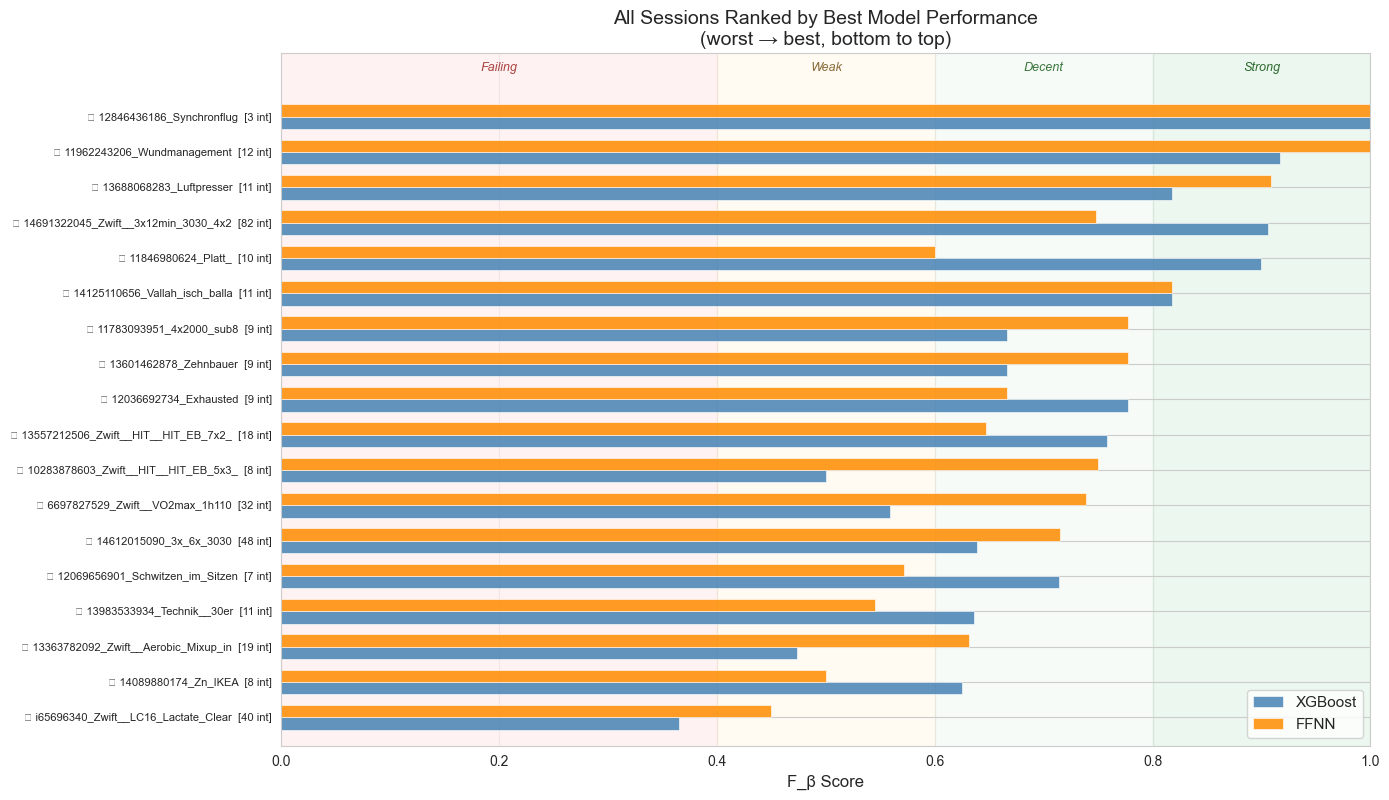

In [2]:
# ============================================================================
# 1. OVERVIEW DASHBOARD: Horizontal bar chart — every session, ranked
# ============================================================================

df_sorted = df_all.sort_values('best_fbeta', ascending=True).reset_index(drop=True)
n = len(df_sorted)

fig, ax = plt.subplots(figsize=(14, max(8, n * 0.45)))

y_pos = np.arange(n)
bar_height = 0.35

ax.barh(y_pos - bar_height/2, df_sorted['xgb_fbeta'], bar_height,
        color='steelblue', alpha=0.85, label='XGBoost', edgecolor='white', linewidth=0.5)
ax.barh(y_pos + bar_height/2, df_sorted['ffnn_fbeta'], bar_height,
        color='darkorange', alpha=0.85, label='FFNN', edgecolor='white', linewidth=0.5)

# Performance zone shading
ax.axvspan(0.0, 0.4, color='#ffcccc', alpha=0.25, zorder=0)
ax.axvspan(0.4, 0.6, color='#fff3cd', alpha=0.25, zorder=0)
ax.axvspan(0.6, 0.8, color='#d4edda', alpha=0.20, zorder=0)
ax.axvspan(0.8, 1.0, color='#c3e6cb', alpha=0.30, zorder=0)

ax.text(0.20, n + 0.3, 'Failing', ha='center', fontsize=9, color='#a94442', fontstyle='italic')
ax.text(0.50, n + 0.3, 'Weak', ha='center', fontsize=9, color='#8a6d3b', fontstyle='italic')
ax.text(0.70, n + 0.3, 'Decent', ha='center', fontsize=9, color='#3c763d', fontstyle='italic')
ax.text(0.90, n + 0.3, 'Strong', ha='center', fontsize=9, color='#2d6a2e', fontstyle='italic')

labels = []
for _, row in df_sorted.iterrows():
    icon = '🚴' if row['sport'] == 'biking' else '🚣'
    short_name = row['session'][:35]
    labels.append(f"{icon} {short_name}  [{row['n_intervals']} int]")

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('F_β Score', fontsize=12)
ax.set_title('All Sessions Ranked by Best Model Performance\n(worst → best, bottom to top)', fontsize=14)
ax.set_xlim(0, 1.0)
ax.set_ylim(-0.8, n + 0.8)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('results/ranked_sessions_overview.png', dpi=200, bbox_inches='tight')
plt.show()

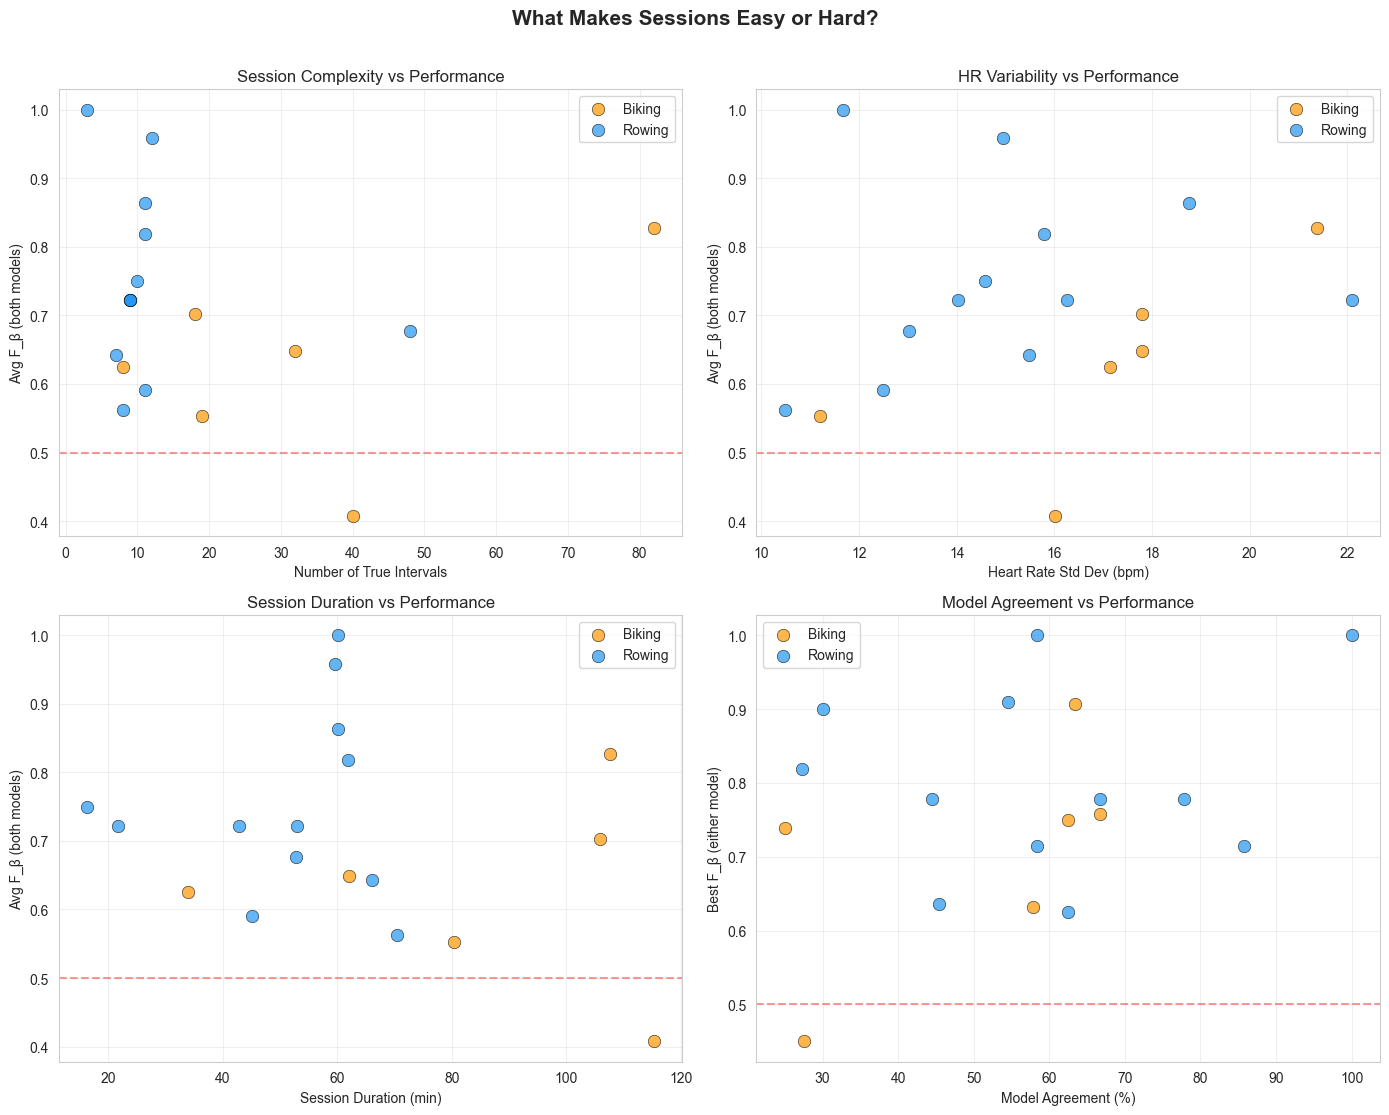

In [3]:
# ============================================================================
# 2. WHAT MAKES SESSIONS EASY OR HARD?
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
sport_colors = {'rowing': '#2196F3', 'biking': '#FF9800'}

# Number of intervals vs avg F_beta
ax = axes[0, 0]
for sport, grp in df_all.groupby('sport'):
    ax.scatter(grp['n_intervals'], grp['avg_fbeta'],
              s=80, alpha=0.7, label=sport.capitalize(),
              color=sport_colors[sport], edgecolors='black', linewidth=0.5)
ax.set_xlabel('Number of True Intervals')
ax.set_ylabel('Avg F_β (both models)')
ax.set_title('Session Complexity vs Performance')
ax.legend()
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.4)
ax.grid(True, alpha=0.3)

# HR variability vs avg F_beta
ax = axes[0, 1]
for sport, grp in df_all.groupby('sport'):
    ax.scatter(grp['hr_std'], grp['avg_fbeta'],
              s=80, alpha=0.7, label=sport.capitalize(),
              color=sport_colors[sport], edgecolors='black', linewidth=0.5)
ax.set_xlabel('Heart Rate Std Dev (bpm)')
ax.set_ylabel('Avg F_β (both models)')
ax.set_title('HR Variability vs Performance')
ax.legend()
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.4)
ax.grid(True, alpha=0.3)

# Session duration vs avg F_beta
ax = axes[1, 0]
for sport, grp in df_all.groupby('sport'):
    ax.scatter(grp['duration_min'], grp['avg_fbeta'],
              s=80, alpha=0.7, label=sport.capitalize(),
              color=sport_colors[sport], edgecolors='black', linewidth=0.5)
ax.set_xlabel('Session Duration (min)')
ax.set_ylabel('Avg F_β (both models)')
ax.set_title('Session Duration vs Performance')
ax.legend()
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.4)
ax.grid(True, alpha=0.3)

# Model agreement vs best F_beta
ax = axes[1, 1]
for sport, grp in df_all.groupby('sport'):
    ax.scatter(grp['agreement_pct'], grp['best_fbeta'],
              s=80, alpha=0.7, label=sport.capitalize(),
              color=sport_colors[sport], edgecolors='black', linewidth=0.5)
ax.set_xlabel('Model Agreement (%)')
ax.set_ylabel('Best F_β (either model)')
ax.set_title('Model Agreement vs Performance')
ax.legend()
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.4)
ax.grid(True, alpha=0.3)

plt.suptitle('What Makes Sessions Easy or Hard?', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results/session_difficulty_factors.png', dpi=200, bbox_inches='tight')
plt.show()

C:\Users\katha\AppData\Local\Temp\ipykernel_17356\3173605056.py:95: UserWarning: Glyph 128692 (\N{BICYCLIST}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\katha\AppData\Local\Temp\ipykernel_17356\3173605056.py:95: UserWarning: Glyph 128675 (\N{ROWBOAT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\katha\AppData\Local\Temp\ipykernel_17356\3173605056.py:96: UserWarning: Glyph 128692 (\N{BICYCLIST}) missing from font(s) Arial.
  plt.savefig('results/per_session_sorted_by_performance.png', dpi=200, bbox_inches='tight')
C:\Users\katha\AppData\Local\Temp\ipykernel_17356\3173605056.py:96: UserWarning: Glyph 128675 (\N{ROWBOAT}) missing from font(s) Arial.
  plt.savefig('results/per_session_sorted_by_performance.png', dpi=200, bbox_inches='tight')
C:\Users\katha\OneDrive - Microsoft 365 der Universität Wien\Masterarbeit\Codes\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128692 (\N{BICYCLIST}) missing from font(s) Arial.
  fig.canvas.print

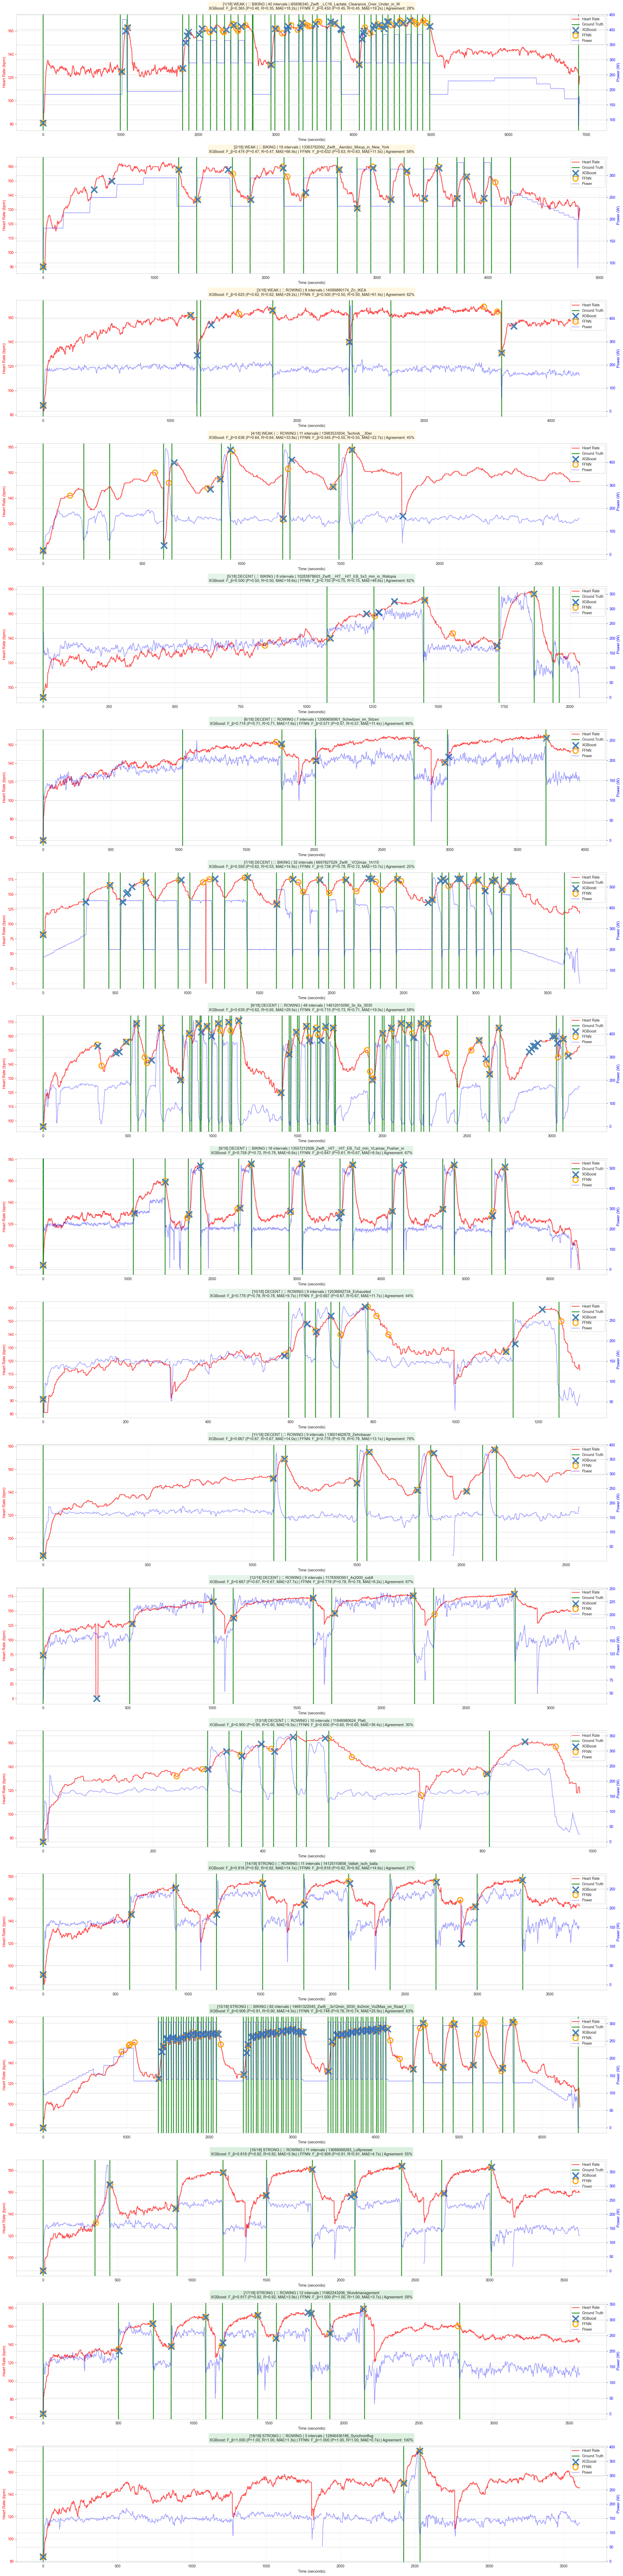

In [4]:
# ============================================================================
# 3. PER-SESSION PLOTS — SORTED WORST → BEST
# ============================================================================

df_plot_order = df_all.sort_values('avg_fbeta', ascending=True).reset_index(drop=True)
n_sessions = len(df_plot_order)

fig, axes = plt.subplots(n_sessions, 1, figsize=(24, 5.5 * n_sessions))
if n_sessions == 1:
    axes = [axes]

for idx, (_, row) in enumerate(df_plot_order.iterrows()):
    sid = row['session']
    xr = xgboost_dict[sid]
    nr = FFNN_dict[sid]
    df = xr['df']
    hr = df['heart_rate'].values
    y_true = xr['y_true']

    ax1 = axes[idx]
    ax2 = ax1.twinx()

    ax1.plot(hr, color='red', alpha=0.7, linewidth=2, label='Heart Rate')

    if 'power' in df.columns:
        ax2.plot(df['power'].values, color='blue', alpha=0.4, linewidth=1.5, label='Power')
        ax2.set_ylabel('Power (W)', fontsize=11, color='blue')
        ax2.tick_params(axis='y', labelcolor='blue')

    gt_cps = np.where(y_true == 1)[0]
    xgb_cps = np.where(xr['y_pred'] == 1)[0]
    ffnn_cps = np.where(nr['y_pred'] == 1)[0]

    for cp in gt_cps:
        if cp < len(hr):
            ax1.axvline(x=cp, color='green', linestyle='-', linewidth=2.5,
                       alpha=0.8, zorder=3, label='Ground Truth' if cp == gt_cps[0] else '')
    for cp in xgb_cps:
        if cp < len(hr):
            ax1.scatter(cp, hr[cp], marker='x', s=300, color='steelblue',
                       linewidths=4, zorder=5, label='XGBoost' if cp == xgb_cps[0] else '')
    for cp in ffnn_cps:
        if cp < len(hr):
            ax1.scatter(cp, hr[cp], marker='o', s=200,
                       facecolors='none', edgecolors='orange',
                       linewidths=3, zorder=4, label='FFNN' if cp == ffnn_cps[0] else '')

    # Color-coded tier
    avg_f = row['avg_fbeta']
    if avg_f >= 0.8:
        tier_color, tier_label = '#c3e6cb', 'STRONG'
    elif avg_f >= 0.6:
        tier_color, tier_label = '#d4edda', 'DECENT'
    elif avg_f >= 0.4:
        tier_color, tier_label = '#fff3cd', 'WEAK'
    else:
        tier_color, tier_label = '#f8d7da', 'FAILING'

    sport_emoji = '🚴' if row['sport'] == 'biking' else '🚣'

    title = (
        f"[{idx+1}/{n_sessions}] {tier_label} | {sport_emoji} {row['sport'].upper()} | "
        f"{row['n_intervals']} intervals | {sid[:55]}\n"
        f"XGBoost: F_β={row['xgb_fbeta']:.3f} (P={row['xgb_precision']:.2f}, R={row['xgb_recall']:.2f}, "
        f"MAE={row['xgb_mae']:.1f}s) | "
        f"FFNN: F_β={row['ffnn_fbeta']:.3f} (P={row['ffnn_precision']:.2f}, R={row['ffnn_recall']:.2f}, "
        f"MAE={row['ffnn_mae']:.1f}s) | "
        f"Agreement: {row['agreement_pct']:.0f}%"
    )

    ax1.set_title(title, fontsize=10.5, pad=12,
                  bbox=dict(boxstyle='round', facecolor=tier_color, alpha=0.6))

    ax1.set_ylabel('Heart Rate (bpm)', fontsize=11, color='red')
    ax1.set_xlabel('Time (seconds)', fontsize=11)
    ax1.tick_params(axis='y', labelcolor='red')
    ax1.grid(True, alpha=0.3)

    # Deduplicated legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    if 'power' in df.columns:
        lines2, labels2 = ax2.get_legend_handles_labels()
        all_lines, all_labels = lines1 + lines2, labels1 + labels2
    else:
        all_lines, all_labels = lines1, labels1
    seen = set()
    unique_lines, unique_labels = [], []
    for line, label in zip(all_lines, all_labels):
        if label not in seen:
            seen.add(label)
            unique_lines.append(line)
            unique_labels.append(label)
    ax1.legend(unique_lines, unique_labels, loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('results/per_session_sorted_by_performance.png', dpi=200, bbox_inches='tight')
plt.show()

In [5]:
# ============================================================================
# 4. PROBLEM SESSIONS — DETAILED BREAKDOWN
# ============================================================================

threshold = 0.6
df_problems = df_all[df_all['best_fbeta'] < threshold].sort_values('best_fbeta').copy()

print(f"Sessions where even the BEST model scores below {threshold}:")
print(f"Found {len(df_problems)} / {len(df_all)} sessions\n")

if len(df_problems) > 0:
    display_cols = [
        'session', 'sport', 'n_intervals', 'duration_min',
        'hr_std', 'xgb_fbeta', 'ffnn_fbeta', 'best_fbeta',
        'xgb_mae', 'ffnn_mae', 'agreement_pct', 'winner'
    ]
    display_df = df_problems[display_cols].copy()
    display_df['session'] = display_df['session'].str[:40]
    display_df = display_df.round(3)
    display(display_df)

    # Characteristics of problem sessions vs good sessions
    df_good = df_all[df_all['best_fbeta'] >= threshold]

    print("\n" + "=" * 60)
    print("PROBLEM vs GOOD SESSIONS — CHARACTERISTICS")
    print("=" * 60)

    compare_stats = pd.DataFrame({
        'Metric': ['Avg intervals', 'Avg duration (min)', 'Avg HR std (bpm)',
                   'Avg HR mean (bpm)', 'Avg agreement (%)', 'Sport: rowing (%)', 'Sport: biking (%)'],
        f'Problem (n={len(df_problems)})': [
            df_problems['n_intervals'].mean(),
            df_problems['duration_min'].mean(),
            df_problems['hr_std'].mean(),
            df_problems['hr_mean'].mean(),
            df_problems['agreement_pct'].mean(),
            100 * (df_problems['sport'] == 'rowing').mean(),
            100 * (df_problems['sport'] == 'biking').mean(),
        ],
        f'Good (n={len(df_good)})': [
            df_good['n_intervals'].mean(),
            df_good['duration_min'].mean(),
            df_good['hr_std'].mean(),
            df_good['hr_mean'].mean(),
            df_good['agreement_pct'].mean(),
            100 * (df_good['sport'] == 'rowing').mean(),
            100 * (df_good['sport'] == 'biking').mean(),
        ],
    }).set_index('Metric').round(1)

    display(compare_stats)
else:
    print("No problem sessions — all sessions have at least one model above threshold.")

Sessions where even the BEST model scores below 0.6:
Found 1 / 18 sessions



,session,sport,n_intervals,duration_min,hr_std,xgb_fbeta,ffnn_fbeta,best_fbeta,xgb_mae,ffnn_mae,agreement_pct,winner
17,i65696340_Zwift__LC16_Lactate_Clearance_,biking,40,115.333,16.015,0.365,0.45,0.45,18.225,19.225,27.5,FFNN



PROBLEM vs GOOD SESSIONS — CHARACTERISTICS


,Problem (n=1),Good (n=17)
Metric,,
Avg intervals,40.0,18.1
Avg duration (min),115.3,58.8
Avg HR std (bpm),16.0,15.6
Avg HR mean (bpm),145.3,148.2
Avg agreement (%),27.5,58.0
Sport: rowing (%),0.0,70.6
Sport: biking (%),100.0,29.4
